### 2026-06-16 - W7-X XICS Raytracing - SULI 2026 L. Alston, Part 1

<hr style="height:10px">

### Summary

This notebook is for performing XICSRT raytracing runs for a SULI project with Leila Alston.

In [1]:
%matplotlib widget
import numpy as np
import os

# Setup the module path.
import sys
sys.path.append(r"C:\Users\leila\Documents\Visual Studio\pppl_xics_2026\xicsrt")
sys.path.append(r"C:\Users\leila\Documents\Visual Studio\pppl_xics_2026\xicsrt_contrib")
sys.path.append(r"C:\Users\leila\Documents\Visual Studio\pppl_xics_2026\xicsrt_analysis")
sys.path.append(r"C:\Users\leila\Documents\Visual Studio\pppl_xics_2026\mirfusion_library")

## Start Logging
import logging
logging.basicConfig(level=logging.DEBUG)
logging.getLogger('matplotlib').setLevel(logging.WARNING)
logging.getLogger('PIL').setLevel(logging.WARNING)
logging.getLogger('h5py').setLevel(logging.WARNING)
logging.getLogger('jax').setLevel(logging.WARNING)

from mirutil import mirprint

# Import xicsrt modules
import xicsrt
from xicsrt.util import profiler

from w7x_npablant import xicsrt_w7x_npablant

In [2]:
config = xicsrt_w7x_npablant.get_config()
config = xicsrt_w7x_npablant.initialize(config)

config['general']['comment'] = """
W7-X run without velocity profile profile.
Based on Op1.2b geometry calibration.

Simple polynomial profiles for emissivity, temperature and velocity.

Full crystal W7-X Ar16+ raytracing simulation with realistic W7-X plasma geometry.
"""

config['general']['number_of_runs'] = 1
config['general']['number_of_iter'] = 1
config['general']['save_images'] = True
config['general']['make_directories'] = True

config['general']['keep_history'] = True

config['general']['output_path'] = r"C:\Users\leila\Documents\Visual Studio\pppl_xics_2026"
config['general']['output_suffix'] = '_00'

config['sources']['plasma']['wout_file'] = r"C:\Users\leila\Documents\Visual Studio\pppl_xics_2026\wout.nc"
config['sources']['plasma']['enable_velocity'] = False
config['sources']['plasma']['enable_flux_compression'] = False
config['sources']['plasma']['time_resolution'] = 1e-3
config['sources']['plasma']['spread'] = np.radians(1.0)
config['sources']['plasma']['xsize'] = 0.15

config['optics']['crystal']['check_size'] = False
config['optics']['detector']['check_size'] = False

lines = {
    'w':3.9492 
    ,'x':3.9660
    ,'y':3.9695
    ,'z':3.9944
}

In [3]:
profiler.resetProfiler()
profiler.startProfiler()

result = xicsrt.raytrace(config)
    
profiler.stopProfiler()
#print('', flush=True)
profiler.report()

INFO:xicsrt.xicsrt_raytrace:Starting run: 1 of 1
INFO:xicsrt.xicsrt_raytrace:Seeding np.random with None
INFO:xicsrt.xicsrt_raytrace:Starting iteration: 1 of 1
C:\Users\leila\Documents\Visual Studio\pppl_xics_2026\DESC\desc\vmec.py:93: UserWarning: VMEC output appears to be from version 8.48 while DESC is only designed for compatibility with VMEC version 9. Some data may not be loaded correctly.
  warnings.warn(
INFO:xicsrt.xicsrt_io:Saved image: C:\Users\leila\Documents\Visual Studio\pppl_xics_2026\xicsrt_crystal__00_0000.tif
INFO:xicsrt.xicsrt_io:Saved image: C:\Users\leila\Documents\Visual Studio\pppl_xics_2026\xicsrt_detector__00_0000.tif
INFO:xicsrt.xicsrt_io:Saved image: C:\Users\leila\Documents\Visual Studio\pppl_xics_2026\xicsrt_crystal__00.tif
INFO:xicsrt.xicsrt_io:Saved image: C:\Users\leila\Documents\Visual Studio\pppl_xics_2026\xicsrt_detector__00.tif



Rays Generated: 4.280e+05
Rays Detected:  3.720e+02
Efficiency:     8.692e-04 ± 4.5e-05 (0.08692%)



INFO:xicsrt.util.profiler:name                      total           single          calls 
INFO:xicsrt.util.profiler:raytrace                  0:01:25.891910  0:01:25.891910       1
INFO:xicsrt.util.profiler:raytrace_single           0:01:25.859756  0:01:25.859756       1
INFO:xicsrt.util.profiler:_raytrace_iter            0:01:20.974281  0:01:20.974281       1
INFO:xicsrt.util.profiler:Bundle Input Generation   0:00:48.150171  0:00:48.150171       1
INFO:xicsrt.util.profiler:Fluxspace from Realspace  0:00:48.150171  0:00:48.150171       1
INFO:xicsrt.util.profiler:Ray Bundle Generation     0:00:03.556266  0:00:00.001124    3165
INFO:xicsrt.util.profiler:generate_rays             0:00:02.910975  0:00:00.000920    3165
INFO:xicsrt.util.profiler:generate_wavelength       0:00:01.764492  0:00:00.000558    3165
INFO:xicsrt.util.profiler:generate_direction        0:00:00.871214  0:00:00.000275    3165
INFO:xicsrt.util.profiler:Dispatcher: raytrace      0:00:00.471682  0:00:00.471682       1

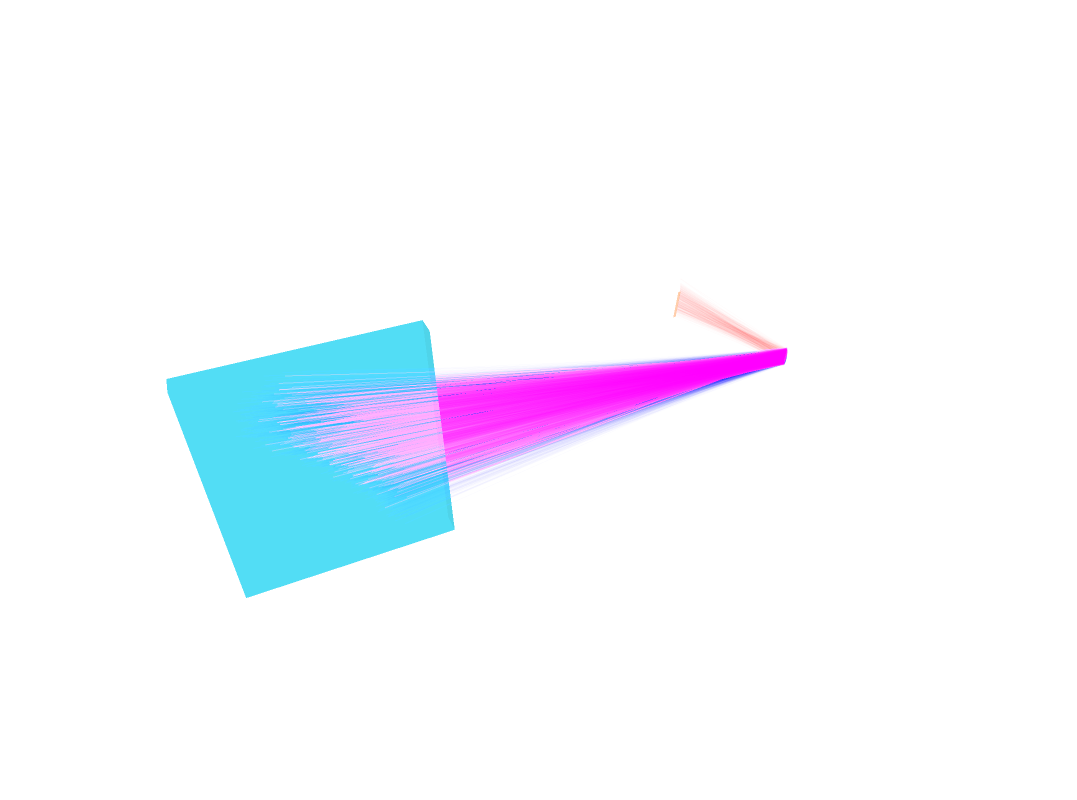

In [5]:
import xicsrt.visual.xicsrt_3d__plotly as xicsrt_3d

fig = xicsrt_3d.figure()
# xicsrt_3d.add_fluxsurfaces(result['config'], range_n=(0+np.pi*4/5, np.pi/10+np.pi*4/5))
xicsrt_3d.add_rays(result)
xicsrt_3d.add_optics(result['config'])
xicsrt_3d.add_sources(result['config'])

fig.update_layout(
    autosize=False,
    width=1000,
    height=800,
)

xicsrt_3d.show()

In [ ]:
import xicsrt.visual.xicsrt_2d__matplotlib as xicsrt_2d
fig = xicsrt_2d.plot_intersect(result, 'detector', aspect='equal')

In [ ]:
import xicsrt.visual.xicsrt_2d__matplotlib as xicsrt_2d
fig = xicsrt_2d.plot_intersect(result, 'detector', aspect='equal')

In [ ]:
import xicsrt.visual.xicsrt_2d__matplotlib as xicsrt_2d
fig = xicsrt_2d.plot_image(result, 'detector')

In [ ]:
from xicsrt import xicsrt_public
obj = xicsrt_public.get_element(config, 'plasma')

In [ ]:
obj.flx_from_car(np.asarray([[5.5, 0.0, 0.0]]))

In [ ]:
import numpy as np
import plotly.graph_objects as go

# 1. Define the dummy function (replace with your actual flx_from_car)
def flx_from_car(coords):
    """
    Expects coords to be an (N, 3) numpy array: [[x1, y1, z1], [x2, y2, z2], ...]
    Returns an array of shape (N,)
    """
    x_vals = coords[:, 0]
    y_vals = coords[:, 1]
    # In this example, z_vals is always 0.0
    z_vals = coords[:, 2] 
    
    # Generate some dummy data (e.g., a 2D sine wave)
    return np.sin(x_vals) * np.cos(y_vals)

meshsize = 500
# 2. Generate the 2D mesh grid limits and resolution
r = np.linspace(4.0, 8.0, meshsize)
z = np.linspace(-1.5, 1.5, meshsize)
R, Z = np.meshgrid(r, z)

# 3. Embed the 2D mesh in 3D coordinates by settin PHI to a constant (e.g., 0.0)
PHI = np.zeros_like(R)+np.pi/10

# Flatten the arrays and stack them to create the (N, 3) coordinate array
# Resulting shape will be (10000, 3) with rows like [5.5, 0.0, 1.0]
points_3d = np.column_stack((R.ravel(), PHI.ravel(), Z.ravel()))

# 4. Calculate function values using your function
values = obj.flx_from_cyl(points_3d)
values = values[:,0]

# 5. Reshape the 1D output values back into the 2D grid shape for plotting
Values_2d = values.reshape(R.shape)

# 6. Generate the filled contour map using Plotly
fig = go.Figure(data=go.Contour(
    x=r,
    y=z,
    z=Values_2d,                # The function outputs plotted as contours
    colorscale='Viridis',       # The color map for the filled contours
    contours=dict(
        showlines=True,         # Show contour lines
        coloring='heatmap',     # Fills the space between contour lines
    )
))

# Update layout for better aesthetics
fig.update_layout(
    title='Filled Contour Plot of flx_from_car Output',
    xaxis_title='R axis',
    yaxis_title='Z axis',

    # Anchor the y-axis to the x-axis with a 1:1 ratio
    yaxis=dict(
        scaleanchor="x",
        scaleratio=1
    ),
    
    width=800,
    height=600
)

# Render the plot
fig.show()